# Diabetes Risk Factor Analysis

## Purpose and Overview

This notebook examines how patient characteristics (glucose, blood pressure, skinfold thickness, insulin, BMI, family-history score, age, and number of pregnancies) relate to diabetes status in a cohort of 768 women. It was prepared so that the data science team at another clinical site can reproduce the analysis exactly and reuse the workflow as a template for their own patient data.

**Workflow:** setup and environment → data source and loading → validation → preparation (cleaning) → descriptive statistics → visualizations → correlation analysis → inferential tests → formal problem definition for predictive modeling → reproducibility check → results and conclusions.

**To run:** open in Google Colab (or locally after installing `requirements.txt`), then choose **Runtime > Restart session and run all**. No other steps are required for the example dataset. To analyze your own site's data, see the Data Source section. Setup instructions, dependencies, and limitations are also documented in the repository README.

## Setup and Environment


**Run this cell first.** It imports every library the notebook uses, sets the random seed that makes all random steps reproducible, and prints the software versions in use.

**Verified environment (September 30, 2026):** Google Colab, Python 3.13.15, pandas 2.2.3, numpy 2.1.3, matplotlib 3.10.0, seaborn 0.13.2, scipy 1.16.3. These versions are pinned in `requirements.txt` in the repository.

- **In Colab:** all packages are preinstalled. Compare the printed versions with those above. If they differ, run `!pip install -r https://raw.githubusercontent.com/JillianMelbourne/Diabetes-Risk-Reproducibility/main/requirements.txt` in a new cell, restart the session, and run all cells again.
- **Locally:** create a virtual environment and run `pip install -r requirements.txt` from the repository root (Python 3.11 or newer).

`RANDOM_SEED = 42` controls every random operation in the notebook. Changing it changes sampled values but should not meaningfully change conclusions.

In [1]:
# --- Imports ---
import sys
import platform

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import scipy
from scipy import stats
from scipy.stats import ttest_ind, mannwhitneyu


# --- Reproducibility settings ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# --- Environment report ---
print("Python:    ", sys.version.split()[0])
print("Platform:  ", platform.platform())
print("pandas:    ", pd.__version__)
print("numpy:     ", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("seaborn:   ", sns.__version__)
print("scipy:     ", scipy.__version__)

Python:     3.13.15
Platform:   Linux-6.6.122+-x86_64-with-glibc2.39
pandas:     2.2.3
numpy:      2.1.3
matplotlib: 3.10.0
seaborn:    0.13.2
scipy:      1.16.3


## Data Source & Provenance


**Dataset:** `Example Dataset_Diabetes.csv` (768 rows × 9 columns), included in this repository under `data/`.

**Origin:** The file has the structure of the Pima Indians Diabetes Database, originally collected by the National Institute of Diabetes and Digestive and Kidney Diseases and distributed through the UCI Machine Learning Repository and Kaggle. It contains 768 female patients aged 21 or older of Pima Indian heritage.

**Role in this project:** This is a public teaching dataset that stands in for patient data from our health system. The workflow is designed so another site can swap in its own data with the same columns.

**How the data is loaded.** The loading cell below tries three sources in order:
1. **Your own file:** if you set `USER_DATA_PATH`, that file is used.
2. **Local copy:** if you cloned the repository, it reads `data/Example Dataset_Diabetes.csv`.
3. **GitHub download:** otherwise, it downloads the dataset from this project's public GitHub repository. This does not require drag and drop upload of data into Google Colab.

**To use your own site's data:** keep the same column names (`Pregnancies`, `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin`, `BMI`, `Pedigree`, `Age`, `Outcome`) and the 0/1 `Outcome` coding.
- *Locally:* place your CSV anywhere and set `USER_DATA_PATH` to its path.
- *In Colab:* drag the file into the Files panel (left sidebar), then set `USER_DATA_PATH = "/content/<your_file_name>.csv"`. Files in Colab are deleted when the runtime resets, so upload again after a reset.

**Regulatory note:** DO NOT COMMIT PROTECTED HEALTH INFORMATION TO A PUBLIC REPOSITORY. If working with PHI use .gitignore

In [2]:
from pathlib import Path
from urllib.parse import quote

# ---- EDIT: Add your data here if needed ----
DATA_FILENAME = "Example Dataset_Diabetes.csv"
USER_DATA_PATH = None    # e.g. "my_site_data.csv" or "/content/my_site_data.csv"
GITHUB_RAW_URL = (
    "https://raw.githubusercontent.com/JillianMelbourne/"
    "Diabetes-Risk-Reproducibility/main/data/" + quote(DATA_FILENAME)
)

def resolve_data_source():
    """Return path or url for selected data source. Error if USER_DATA_PATH does not exist."""
    if USER_DATA_PATH:
        path = Path(USER_DATA_PATH)
        # error if file does not exist at USER_DATA_PATH
        if not path.exists():
            raise FileNotFoundError(
                f"USER_DATA_PATH was set to '{USER_DATA_PATH}' but no file exists there. "
                "Check the path, or re-upload the file if the Colab runtime was reset."
            )
        return str(path), "user-specified file"
    # look if DATA_FILENAME exists locally
    for candidate in (Path("data") / DATA_FILENAME, Path(DATA_FILENAME)):
        if candidate.exists():
            return str(candidate), "local repository copy"
    # look if data is on GitHub
    return GITHUB_RAW_URL, "downloaded from GitHub repository"

# load data
def load_data():
    source, origin = resolve_data_source()
    data = pd.read_csv(source)
    print(f"Loaded {data.shape[0]} rows x {data.shape[1]} columns ({origin})")
    return data

df = load_data()
df.head()

Loaded 768 rows x 9 columns (downloaded from GitHub repository)


,Pregnancies,Glucose,D_BP,Skin_Thickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Data Validation

**Purpose.** Before any analysis, this step confirms that the expected dataset was loaded correctly. .

**Required checks (the notebook stops with an error if any fail):** all nine expected columns are present, all are numeric, and `Outcome` contains only 0 and 1.

**Warnings (reported, but the analysis continues):** extra columns, a row count different from the example dataset (768), or duplicate rows.

**Missing values.** In `Glucose`, `D_BP`, `Skin_Thickness`, `Insulin`, and `BMI`, a value of 0 is physiologically impossible and indicates a missing measurement, so these values are represented in the output as zeros = missing.

**Expected result for the example dataset:** "All required checks passed: 768 rows x 9 columns; Outcome 0 = 500, Outcome 1 = 268", with no warnings, and zero counts of Glucose 5, D_BP 35, Skin_Thickness 227, Insulin 374, BMI 11.

*If you use other data:* update `EXPECTED_COLUMNS`, `ZERO_IS_MISSING`, and `EXPECTED_ROWS` at the top of the cell.

In [3]:
# ---- Edit these if you use a different dataset ----
EXPECTED_COLUMNS = ["Pregnancies", "Glucose", "D_BP", "Skin_Thickness",
                    "Insulin", "BMI", "Pedigree", "Age", "Outcome"]
ZERO_IS_MISSING = ["Glucose", "D_BP", "Skin_Thickness", "Insulin", "BMI"]  # 0 is physiologically impossible
EXPECTED_ROWS = 768  # update if you use new data


def validate_dataset(data):
    """Throw an error if the data cannot be analyzed, warn about
   data quality issues, and return summary table."""
    # --- Required checks: stop if any fail ---
    # error if missing columns
    missing = set(EXPECTED_COLUMNS) - set(data.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    # error if non-numeric data
    non_numeric = data[EXPECTED_COLUMNS].select_dtypes(exclude="number").columns.tolist()
    if non_numeric:
        raise ValueError(f"These columns should be numeric but are not: {non_numeric}")
    # error if outcome data contains any number other than 1 or 0
    if not data["Outcome"].isin([0, 1]).all():
        raise ValueError("Outcome must contain only 0 and 1, with no missing values")

    # --- Potential data issues that won't disrupt future steps ---
    extra = sorted(set(data.columns) - set(EXPECTED_COLUMNS))
    if extra: # print warning if extra columns are present
        print(f"WARNING: extra columns will be ignored: {extra}")
    if len(data) != EXPECTED_ROWS: #print warning if expected row count is not equal toa ctual row count
        print(f"WARNING: {len(data)} rows (example dataset has {EXPECTED_ROWS})")
    n_dup = data.duplicated().sum()
    if n_dup: # print warning if dupliacte rows
        print(f"WARNING: {n_dup} duplicate rows")

    # --- Summary ---
    counts = data["Outcome"].value_counts()
    print(f"All required checks passed: {data.shape[0]} rows x {data.shape[1]} columns; "
          f"Outcome 0 = {counts.get(0, 0)}, Outcome 1 = {counts.get(1, 0)}")

    cols = data[EXPECTED_COLUMNS]
    return pd.DataFrame({
        "dtype": cols.dtypes.astype(str),
        "min": cols.min(),
        "max": cols.max(),
        "missing (NaN)": cols.isna().sum(),
        "zeros = missing": (cols == 0).sum().where(cols.columns.isin(ZERO_IS_MISSING), "-"),
    })


validate_dataset(df)


All required checks passed: 768 rows x 9 columns; Outcome 0 = 500, Outcome 1 = 268


,dtype,min,max,missing (NaN),zeros = missing
Pregnancies,int64,0.000,17.00,0,-
Glucose,int64,0.000,199.00,0,5
D_BP,int64,0.000,122.00,0,35
Skin_Thickness,int64,0.000,99.00,0,227
Insulin,int64,0.000,846.00,0,374
BMI,float64,0.000,67.10,0,11
Pedigree,float64,0.078,2.42,0,-
Age,int64,21.000,81.00,0,-
Outcome,int64,0.000,1.00,0,-


## Data Preparation

**Purpose.** This step corrects data errors before analysis and records the chnage. The original data are preserved as `raw` for comparison.

**Steps:**
1. **Remove exact duplicate rows.** None are found in the example dataset.
2. **Convert all columns to numeric.** Any non-numeric entry, such as text typed into a numeric field, becomes missing and is reported. None are found in the example dataset.
3. **Set implausible values to missing.** Each characteristic has a plausible range defined in `BOUNDS`. Values outside the range are set to missing (`NaN`) and summarized in output. In the example dataset, this converts physiologically impossible values such as zeros (Glucose 5, D_BP 35, Skin_Thickness 227, Insulin 374, BMI 11) and one skinfold value of 99 mm to NaN.

**Decision: missing values are left missing, values are not imputed and incomplete rows are not dropped** Each analysis uses all patients with the values it needs, and the number of patients used is reported with each result. Dropping incomplete rows would discard about half the cohort (only 392 of 768 patients have all eight measurements), and imputation would add assumptions this analysis does not require.


*Other sites:* review `BOUNDS` for your population. For example, lower the minimum `Age` if you include patients younger than 21.

In [4]:
raw = df.copy()
df = df.drop_duplicates()
print(f"Dropped {len(raw) - len(df)} exact duplicate rows ({len(df)} remaining)")

# --- Checker function for coerced values ---
def report_coerced_values(df, raw, cols):
    """Print the values that were coerced to NaN during conversion."""
    if isinstance(cols, str):
        cols = [cols]

    # create boolean mask for newly coerced values (NaN in df but not in raw)
    newly_coerced = df[cols].isna() & raw[cols].notna()

    if not newly_coerced.any().any():  # no coerced values in any column
            print("No values coerced to NaN")
            return

    # print out the values that were coerced to NaN for each column
    for col in cols:
        bad = raw.loc[newly_coerced[col], col]  # pull value from raw df where it was coerced to NaN in df
        if len(bad):  # skip columns with no coerced values
            print(f"--- {col} ({len(bad)} coerced) ---")  # print column name and number of coerced values
            print(bad.value_counts())



# convert the columns to numeric, coercing errors to NaN
df[EXPECTED_COLUMNS] = df[EXPECTED_COLUMNS].apply(pd.to_numeric, errors="coerce")

# check for coerced values in expected columns
report_coerced_values(df, raw, EXPECTED_COLUMNS)

# --- Set implausible values to NaN---
#  bounds for physiologically plausible values
BOUNDS = {
    "Pregnancies":    (0, 20),     # count; 0 is valid
    "Glucose":        (20, 500),   # mg/dL, 2-hour oral glucose tolerance test; 0 = not measured
    "D_BP":           (20, 150),   # mm Hg, diastolic; 0 = not measured
    "Skin_Thickness": (1, 80),     # mm, triceps skinfold; 0 = not measured, >80 is implausible
    "Insulin":        (1, 1000),   # µU/mL, 2-hour serum insulin; 0 = not measured
    "BMI":            (10, 80),    # kg/m²; 0 = not measured
    "Pedigree":       (0, 3),      # unitless family-history score; no fixed maximum, 3 is generous
    "Age":            (21, 110),   # years; this cohort enrolled women aged 21+ (lower this for other sites)
}

# loop through the bounds dictionary and set values outside the bounds to NaN
for col, (lo, hi) in BOUNDS.items():
    mask = ~df[col].between(lo, hi) & df[col].notna()   # recorded values outside the range
    if mask.any():
        print(f"{col}: {mask.sum()} values outside [{lo}, {hi}] set to NaN ->",
              df.loc[mask, col].value_counts().to_dict())
    df.loc[mask, col] = np.nan

# --- Summarize data cleaning---

cleaning_summary = pd.DataFrame({
    "n_available": df[EXPECTED_COLUMNS].notna().sum(),
    "% missing": (100 * df[EXPECTED_COLUMNS].isna().mean()).round(1),
})
print(f"Rows with no missing values: {len(df.dropna())} of {len(df)}")
cleaning_summary

Dropped 0 exact duplicate rows (768 remaining)
No values coerced to NaN
Glucose: 5 values outside [20, 500] set to NaN -> {0: 5}
D_BP: 35 values outside [20, 150] set to NaN -> {0: 35}
Skin_Thickness: 228 values outside [1, 80] set to NaN -> {0: 227, 99: 1}
Insulin: 374 values outside [1, 1000] set to NaN -> {0: 374}
BMI: 11 values outside [10, 80] set to NaN -> {0.0: 11}
Rows with no missing values: 392 of 768


,n_available,% missing
Pregnancies,768,0.0
Glucose,763,0.7
D_BP,733,4.6
Skin_Thickness,540,29.7
Insulin,394,48.7
BMI,757,1.4
Pedigree,768,0.0
Age,768,0.0
Outcome,768,0.0


## Descriptive Statistics


### Mean and Standard Deviation by Diabetes Outcome

**Purpose.** This section describes *mean* and *standard deviation* which quanitfy  characteristics of the participant population. We will use the **mean**, or average, of each data type to compare how the typical patient with diabetes differs from the typical patient without it. We will use the **standard deviation**, or spread, of each metric to undetstand how different patients within each group are from each other.

For each characteristic, the mean and standard deviation are calculated separately for patients without diabetes (`Outcome` = 0, n = 500) and with diabetes (`Outcome` = 1, n = 268):

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i
\qquad\qquad
s = \sqrt{\frac{1}{n-1}\sum_{i=1}^{n}\left(x_i - \bar{x}\right)^2}
$$

Here $x_i$ is one patient's recorded value (for example, her `Glucose` in mg/dL), $\bar{x}$ is the group's mean, $s$ is the group's standard deviation, and $n$ is the number of patients in that group with a **recorded** value. Because of data missigness, $n$ is smaller for some variables. `Insulin` is available for only 264 patients without diabetes and 130 with diabetes, so its summarizes about half the cohort.

To compare characteristics measured in different units (mg/dL, kg/m², years), the difference between group means is also expressed in standard deviations:

$$
d = \frac{\bar{x}_{1} - \bar{x}_{0}}{s_{p}},
\qquad
s_{p} = \sqrt{\frac{(n_0 - 1)s_0^2 + (n_1 - 1)s_1^2}{n_0 + n_1 - 2}}
$$

where $s_p$ is the pooled standard deviation of the two groups. A value of $d = 1$ means the groups' means are one typical patient-to-patient spread apart.

**Results from Example Dataset.**

- **Glucose separates diabetic patients from controls.** Patients with diabetes average 142.3 mg/dL (SD 29.6) versus 110.6 mg/dL (SD 24.8) without diabetes. The 32 mg/dL gap is larger than either group's SD ($d$ = 1.19), so the two groups' glucose distributions are shifted. This is expected, since glucose tolerance is how diabetes is diagnosed.
- **BMI, Insulin, Skin_Thickness, and Age show moderate differences between groups** ($d$ between 0.5 and 0.7). For example, mean BMI is 35.4 vs. 30.9 kg/m² (SD about 6.6 in both groups), and mean age is 37.1 vs. 31.2 years. Patients with diabetes are heavier and older on average, but many individual patients in the two groups overlap.
- **Pregnancies, Pedigree, and diastolic blood pressure (D_BP) differ least between groups** ($d$ under 0.5). Mean D_BP is 75.3 vs. 70.9 mm Hg, which is a small between group difference relative to higher SD. Similarly there seem to be small between group differences in pregnancies and pedigree.

**Where the mean can be misleading.** When the SD is large relative to the mean, the distribution is skewed and the mean is pulled toward a few extreme patients. `Insulin` is a good example of this in the data. Among patients with diabetes, the mean is 206.8 µU/mL but the SD is 132.7 and the median is 169.5. Patients without diabetes show the same pattern (mean 130.3, median 102.5). `Pregnancies` and `Pedigree` are also right-skewed. This informs downstream analytic choices, such as opting for nonparametric tests.



In [5]:
# define summary columns as all columns except for Outcome
# note that code may be faulty if you have extra non-numeric columns
SUMMARY_COLUMNS = [c for c in EXPECTED_COLUMNS if c != "Outcome"]

# n, mean, and SD for each characteristic
mean_sd_table = (
    df.groupby("Outcome")[SUMMARY_COLUMNS]
      .agg(["count", "mean", "std", "median"])
      .T
      .unstack()
      .rename(columns={0: "No diabetes", 1: "Diabetes"}, level=0)
      .round(2)
)
mean_sd_table



Outcome        No diabetes                         Diabetes                  \
                     count    mean     std  median    count    mean     std   
Pregnancies          500.0    3.30    3.02    2.00    268.0    4.87    3.74   
Glucose              497.0  110.64   24.78  107.00    266.0  142.32   29.60   
D_BP                 481.0   70.88   12.16   70.00    252.0   75.32   12.30   
Skin_Thickness       361.0   27.24   10.03   27.00    179.0   32.63    9.09   
Insulin              264.0  130.29  102.48  102.50    130.0  206.85  132.70   
BMI                  491.0   30.86    6.56   30.10    266.0   35.41    6.61   
Pedigree             500.0    0.43    0.30    0.34    268.0    0.55    0.37   
Age                  500.0   31.19   11.67   27.00    268.0   37.07   10.97   

Outcome                 
                median  
Pregnancies       4.00  
Glucose         140.00  
D_BP             74.50  
Skin_Thickness   32.00  
Insulin         169.50  
BMI              34.30  
Pedigree          0.45  
Age              36.00

The table below expresses each group difference as Cohen's $d$ (difference in means divided by the pooled standard deviation; Cohen, 1988), sorted from largest to smallest, so that characteristics measured in different units can be compared directly.

In [6]:
# Calculate Cohen's d for each metric
# note that code may be faulty if you have extra non-numeric columns
group_stats = df.groupby("Outcome")[SUMMARY_COLUMNS].agg(["count", "mean", "std"]).T.unstack()
n0, m0, s0 = group_stats[(0, "count")], group_stats[(0, "mean")], group_stats[(0, "std")]
n1, m1, s1 = group_stats[(1, "count")], group_stats[(1, "mean")], group_stats[(1, "std")]

pooled_sd = np.sqrt(((n0 - 1) * s0**2 + (n1 - 1) * s1**2) / (n0 + n1 - 2))

effect_sizes = pd.DataFrame({
    "mean difference (diabetes - no diabetes)": m1 - m0,
    "pooled SD": pooled_sd,
    "d": (m1 - m0) / pooled_sd,
}).round(2).sort_values("d", ascending=False)

effect_sizes

,mean difference (diabetes - no diabetes),pooled SD,d
Glucose,31.68,26.56,1.19
BMI,4.55,6.58,0.69
Insulin,76.56,113.32,0.68
Skin_Thickness,5.40,9.73,0.55
Age,5.88,11.43,0.51
Pregnancies,1.57,3.29,0.48
Pedigree,0.12,0.33,0.37
D_BP,4.44,12.21,0.36


## Visualizations

### Distributions of Glucose and BMI

These histograms show how two key characteristics are distributed across all patients, using the cleaned data (impossible zero values were set to missing and are excluded). Each bar counts the number of patients whose value falls within that range.

- **Glucose** (n = 763): plasma glucose 2 hours into an oral glucose tolerance test, in mg/dL. Values range from 44 to 199 mg/dL. The distribution is centered just below 120 (median 117, mean 121.7) with a mild right tail, meaning a smaller group of patients has markedly elevated glucose.
- **BMI** (n = 757): body mass index in kg/m². Values range from 18.2 to 67.1. The distribution is centered around 32 (median 32.3, mean 32.5), which is in the obese range (≥ 30). A few patients have very high values above 50.

These plots describe each variable on its own. The figures that follow examine how they relate to the diabetes outcome and to each other.

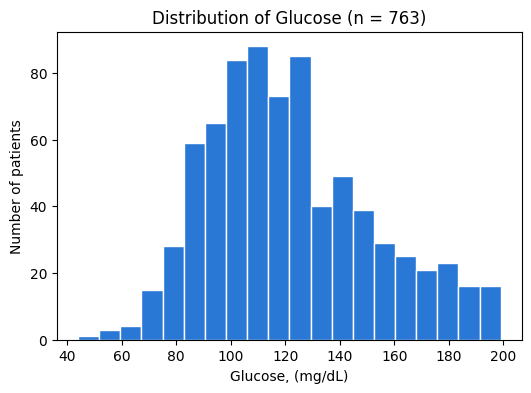

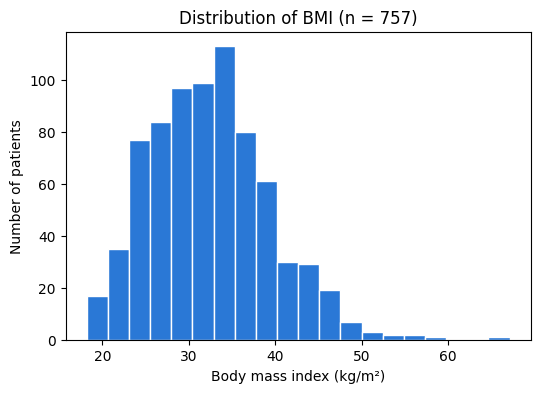

In [7]:
for col, label in [("Glucose", "Glucose, (mg/dL)"),
                   ("BMI", "Body mass index (kg/m²)")]:
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(df[col].dropna(), bins=20, color="#2a78d6", edgecolor="white")
    ax.set_title(f"Distribution of {col} (n = {df[col].notna().sum()})")
    ax.set_xlabel(label)
    ax.set_ylabel("Number of patients")
    plt.show()

### Figure 1: Glucose by Diabetes Outcome

This figure compares glucose (mg/dL, vertical axis) between patients without diabetes (`Outcome` = 0, n = 497, blue) and with diabetes (`Outcome` = 1, n = 266, orange). Each dot is one patient. Dots are spread horizontally only so overlapping values stay visible. The box covers the middle 50% of patients in each group (the interquartile range), the black line inside the box marks the median, and the whiskers extend to the most extreme values within 1.5 times the interquartile range. From this plot, we can see that patients with diabetes have higher blood glucose compared to controls.

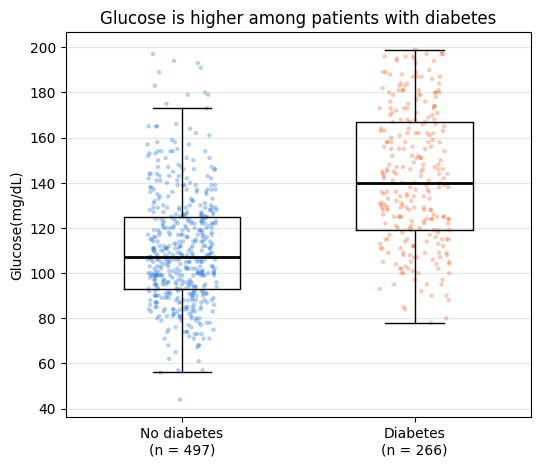

In [8]:
OUTCOME_LABELS = {0: "No diabetes", 1: "Diabetes"}
OUTCOME_COLORS = {0: "#2a78d6", 1: "#eb6834"}   # blue / orange, distinguishable with color blindness

fig, ax = plt.subplots(figsize=(6, 5))
groups = [df.loc[df["Outcome"] == k, "Glucose"].dropna() for k in (0, 1)]

# Individual patients as points, spread horizontally - used random seed to ensure reproducibility
rng = np.random.default_rng(RANDOM_SEED)
for i, (k, values) in enumerate(zip((0, 1), groups), start=1):
    x = i + rng.uniform(-0.15, 0.15, len(values))
    ax.scatter(x, values, s=10, alpha=0.35, color=OUTCOME_COLORS[k], edgecolors="none")

# Box plot on top: median line, middle 50% box, whiskers to 1.5 x IQR
ax.boxplot(groups, positions=[1, 2], widths=0.5, showfliers=False,
           medianprops={"color": "black", "linewidth": 2})

ax.set_xticks([1, 2])
ax.set_xticklabels([f"{OUTCOME_LABELS[k]}\n(n = {len(v)})" for k, v in zip((0, 1), groups)])
ax.set_ylabel("Glucose(mg/dL)")
ax.set_title("Glucose is higher among patients with diabetes")
ax.grid(axis="y", color="0.9")
ax.set_axisbelow(True)
plt.show()

### Figure 2: BMI vs. Glucose by Diabetes Outcome

This scatter plot shows body mass index (kg/m², horizontal axis) against  glucose (mg/dL, vertical axis) for the 752 patients with both values recorded. Each dot is one patient, colored by diabetes outcome: blue for no diabetes and orange for diabetes. This visualization demonstrates that patients with diabetes on average have higher glucose compared controls, though glucose and BMI are only weakly related to each other. Additionally patients with diabetes appear to have some higher BMI outliers compared to controls.

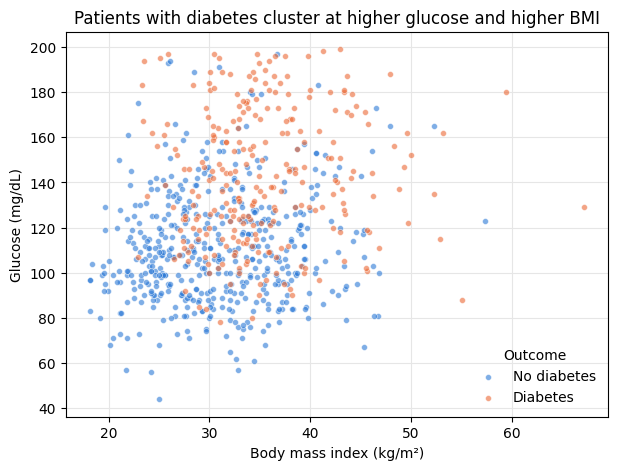

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
for k in (0, 1):
    sub = df[df["Outcome"] == k]
    ax.scatter(sub["BMI"], sub["Glucose"], s=18, alpha=0.6, color=OUTCOME_COLORS[k],
               edgecolors="white", linewidths=0.5, label=OUTCOME_LABELS[k])

ax.set_xlabel("Body mass index (kg/m²)")
ax.set_ylabel("Glucose (mg/dL)")
ax.set_title("Patients with diabetes cluster at higher glucose and higher BMI")
ax.legend(title="Outcome", frameon=False, loc="lower right")
ax.grid(color="0.9")
ax.set_axisbelow(True)
plt.show()


## Correlation Analysis

**Purpose.** This section summarizes the strength of the relationship between different variables, including each characteristic's association with the diabetes outcome. This shows which characteristics carry overlapping information and which relate most closely to diabetes.

**Choice of method: Spearman's rank correlation (ρ).**
- **Pearson's correlation** measures straight-line relationships and is sensitive to skewed distributions and extreme values. Several variables here are right skewed (`Insulin`, `Pedigree`, `Age`), `Pregnancies` is a count, and `Insulin` contains a few very high values, so Pearson coefficients heavily impacted by a handful of patients.
- **Spearman's ρ** is Pearson's correlation computed on the *ranks* of the values. It captures any consistently increasing or decreasing relationship, not just a straight line, and is robust to skew and outliers. It ranges from −1 (perfect negative) through 0 (no monotonic relationship) to +1 (perfect positive). This is the test we will use.
- **Phi_K** is designed for datasets that mix many categorical and continuous variables. This dataset has only one categorical variable, the binary `Outcome`. For a binary variable coded 0/1, Spearman's ρ still indicates the direction and relative strength of association with each characteristic.

**Missing data.** Correlations use all patients with both values recorded for each pair (pairwise deletion). Most pairs are based on 730–768 patients, but any pair involving `Insulin` only includes ~393 patients, so those coefficients are less precise.

**How to read the heatmap.** Each cell shows ρ for the pair of variables on its row and column. Red indicates a positive association, blue a negative one, and gray none. Darker colors mean stronger associations. Each pair appears once, in the lower triangle.

**Interpretation (example dataset).** All notable correlations are positive, and none exceed 0.7 (by rough convention, |ρ| < 0.3 is weak, 0.3–0.5 moderate, > 0.5 strong).

- **Association with diabetes:** `Glucose` has the strongest association with `Outcome` (ρ = 0.48), followed by `Insulin` (0.38), `BMI` (0.31), and `Age` (0.31). `Skin_Thickness`, `Pregnancies`, `D_BP`, and `Pedigree` are weakly associated (0.18–0.26). These findings support some of our group-based descriptive statistics from earlier.
- **`BMI` and `Skin_Thickness` (ρ = 0.69, strong):** both measure body fat, so they carry largely overlapping information.
- **`Glucose` and `Insulin` (ρ = 0.66, strong):** Insulin is released in response to rising glucose, so it makes sense that these values would be correlated.
- **`Age` and `Pregnancies` (ρ = 0.61, strong):** older women have had more time to have children, so it makes sense that these values would be correlated.
- **`Pedigree`** (family-history score) is nearly unrelated to every other characteristic (|ρ| ≤ 0.14), so it adds information the clinical measurements do not.

**Correlation is not causation.** These are associations in cross-sectional data. They do not show that any characteristic causes diabetes, and shared factors such as age can create correlations between variables that do not directly affect each other.

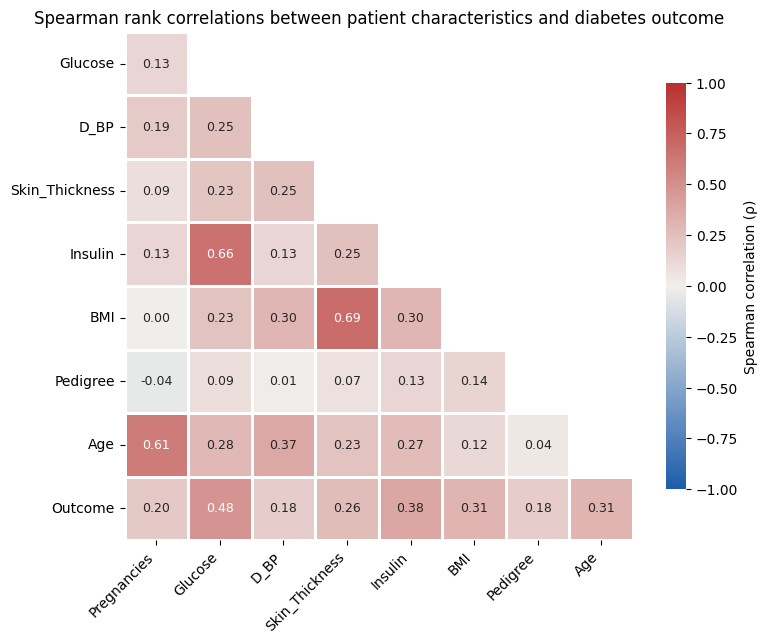

In [10]:

# Spearman rank correlation; pandas uses all patients with both values recorded for each pair
spearman_corr = df[EXPECTED_COLUMNS].corr(method="spearman")

# Diverging colormap: blue (negative) -> neutral gray (0) -> red (positive)
corr_cmap = LinearSegmentedColormap.from_list("corr", ["#1c5cab", "#f0efec", "#b8312f"])

corr_plot = spearman_corr.iloc[1:, :-1]                     # drop the empty first row and last column
mask = np.triu(np.ones_like(corr_plot, dtype=bool), k=1)   # show each pair once (lower triangle)

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr_plot, mask=mask, cmap=corr_cmap, vmin=-1, vmax=1, center=0,
            annot=True, fmt=".2f", annot_kws={"size": 9}, linewidths=1, linecolor="white",
            square=True, cbar_kws={"label": "Spearman correlation (ρ)", "shrink": 0.8}, ax=ax)
ax.set_title("Spearman rank correlations between patient characteristics and diabetes outcome")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Inferential Analysis

### Test 1: Welch's t-test — does mean glucose differ by diabetes outcome?

**Purpose.** To test whether the difference in mean glucose between patients with and without diabetes (142.3 vs. 110.6 mg/dL) is larger than would be expected from chance variation alone.

**Method.** Welch's t-test compares two group means without assuming the groups have equal variances. This is necessary because the groups differ in size (n = 266 vs. 497) and in spread (SD 29.6 vs. 24.8).
$$
t = \frac{\bar{x}_1 - \bar{x}_0}{\sqrt{\dfrac{s_1^2}{n_1} + \dfrac{s_0^2}{n_0}}}
$$

where $\bar{x}_1, s_1, n_1$ are the mean, standard deviation, and number of patients with recorded glucose in the diabetes group, and $\bar{x}_0, s_0, n_0$ are the same for the no-diabetes group.

**Hypotheses:** $H_0: \mu_1 = \mu_0$ (mean glucose is the same in both groups) versus $H_1: \mu_1 \neq \mu_0$, at significance level $\alpha = 0.05$.

In [11]:
def welch_t_test(data, variable, outcome="Outcome"):
    """Welch's t-test comparing the mean of `variable` between outcome groups (missing values excluded)."""
    g1 = data.loc[data[outcome] == 1, variable].dropna()   # diabetes
    g0 = data.loc[data[outcome] == 0, variable].dropna()   # no diabetes
    result = ttest_ind(g1, g0, equal_var=False)
    ci = result.confidence_interval(0.95)
    print(f"{variable}: n = {len(g1)} (diabetes) vs. {len(g0)} (no diabetes)")
    print(f"Mean difference = {g1.mean() - g0.mean():.1f} (95% CI {ci.low:.1f} to {ci.high:.1f})")
    print(f"t = {result.statistic:.2f}, df = {result.df:.1f}, p = {result.pvalue:.2e}")
    return result

glucose_ttest = welch_t_test(df, "Glucose")

Glucose: n = 266 (diabetes) vs. 497 (no diabetes)
Mean difference = 31.7 (95% CI 27.5 to 35.9)
t = 14.88, df = 466.0, p = 2.84e-41


**Result.** Mean glucose was 31.7 mg/dL higher among patients with diabetes (95% CI 27.5 to 35.9 mg/dL; Welch's t = 14.88, df = 466, p < 0.001). We reject $H_0$. A difference this large would be extremely unlikely if mean glucose were truly equal in the two groups.

### Test 2: Mann–Whitney U test — does BMI differ by diabetes outcome?

**Purpose.** To test whether patients with diabetes tend to have higher BMI than patients without diabetes. BMI was the second-strongest group difference in the descriptive statistics ($d$ = 0.69).

**Description of Methods.** The t-test compares means and works best when data are roughly symmetric. The Mann–Whitney U test is robust to the skew and extreme values seen in this dataset (BMI ranges up to 67.1 kg/m²). It is also the rank-based counterpart to the Spearman correlations used above.

$$
U_1 = R_1 - \frac{n_1(n_1 + 1)}{2}
$$

where $R_1$ is the sum of the ranks of the $n_1$ patients with diabetes after all $n_0 + n_1$ BMI values are ranked together. $U_1$ counts how many (diabetes, no-diabetes) patient pairs have the diabetes patient with the higher BMI. Dividing by the total number of pairs gives an intuitive effect size, the **probability of superiority**:

$$
\hat{P}(X_1 > X_0) = \frac{U_1}{n_1 \, n_0}
$$

the estimated probability that a randomly chosen patient with diabetes has a higher BMI than a randomly chosen patient without diabetes. A value of 0.5 means no difference.

**Hypotheses:** $H_0$: BMI values in the two groups come from the same distribution, so $P(X_1 > X_0) = 0.5$. $H_1$: one group tends to have higher BMI. Significance level $\alpha = 0.05$.

In [12]:
def mann_whitney_test(data, variable, outcome="Outcome"):
    """Mann-Whitney U test comparing `variable` between outcome groups (missing values excluded)."""
    g1 = data.loc[data[outcome] == 1, variable].dropna()   # diabetes
    g0 = data.loc[data[outcome] == 0, variable].dropna()   # no diabetes
    result = mannwhitneyu(g1, g0, alternative="two-sided")
    prob_superiority = result.statistic / (len(g1) * len(g0))
    print(f"{variable}: n = {len(g1)} (diabetes) vs. {len(g0)} (no diabetes)")
    print(f"Median = {g1.median():.1f} vs. {g0.median():.1f}")
    print(f"U = {result.statistic:.0f}, p = {result.pvalue:.2e}")
    print(f"Probability of superiority = {prob_superiority:.2f}")
    return result

bmi_mannwhitney = mann_whitney_test(df, "BMI")

BMI: n = 266 (diabetes) vs. 491 (no diabetes)
Median = 34.3 vs. 30.1
U = 89731, p = 1.82e-17
Probability of superiority = 0.69


**Result.** Patients with diabetes had higher BMI (median 34.3 vs. 30.1 kg/m²; Mann–Whitney U = 89,731, p < 0.001; n = 266 and 491). We reject $H_0$. The probability of superiority is 0.69: a randomly chosen patient with diabetes has a higher BMI than a randomly chosen patient without diabetes about 69% of the time, compared with 50% if BMI were unrelated to the outcome, though the BMI distributions of the two groups overlap substantially, as Figure 2 shows.

## Data, Statistics, and the Machine Learning Workflow

### Formalizing the Diabetes Prediction Problem

The descriptive statistics, visualizations, and hypothesis tests above each examined **one to two patient characteristic at a time** in relation to diabetes. The next step in this workflow is predictive modeling which can leverage multiple characteristics together to predict whether a patient has diabetes. This section outlines what that process would look like for this data.

Each row of the dataset is one patient. We denote the dataset as

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n},
\qquad
x_i \in \mathbb{R}^{8},
\qquad
y_i \in \{0, 1\},
\qquad
n = 768,
$$

where:

- $\mathcal{D}$ is the complete set of 768 patients in the example dataset.
- $i = 1, 2, \ldots, 768$ indexes an individual patient (one row of the data).
- $x_i$ is the **feature vector** for patient $i$, containing her $p = 8$ recorded characteristics (all columns except `Outcome`).

- $y_i$ is the **target**: the value of `Outcome` for patient $i$, where
$y_i = 1$ means the patient has diabetes and $y_i = 0$ means she does not. In this dataset, 268 patients (34.9%) have $y_i = 1$ and 500 (65.1%) have $y_i = 0$.

For this dataset, each patient's feature vector is

$$
x_i =
\begin{bmatrix}
\text{Pregnancies}_i \\
\text{Glucose}_i \\
\text{D}\_\text{BP}_i \\
\text{Skin}\_\text{Thickness}_i \\
\text{Insulin}_i \\
\text{BMI}_i \\
\text{Pedigree}_i \\
\text{Age}_i
\end{bmatrix}
\qquad
y_i = \text{Outcome}_i \in \{0, 1\}
$$

| Feature | Meaning | Units |
|---|---|---|
| `Pregnancies` | Number of prior pregnancies | count |
| `Glucose` | Plasma glucose, 2-hour oral glucose tolerance test | mg/dL |
| `D_BP` | Diastolic blood pressure | mm Hg |
| `Skin_Thickness` | Triceps skinfold thickness | mm |
| `Insulin` | 2-hour serum insulin | µU/mL |
| `BMI` | Body mass index | kg/m² |
| `Pedigree` | Diabetes pedigree function (family-history score) | unitless |
| `Age` | Age | years |

Because the target takes only two values, this is a **binary classification** problem. A model learns an estimated prediction function

$$
\hat{f} : \mathbb{R}^{8} \rightarrow \{0, 1\}
$$

that maps a patient's eight characteristics to a predicted diabetes status, $\hat{y}_i = \hat{f}(x_i)$. The hat indicates that $\hat{f}$ is estimated from data and approximates the true, unknown relationship between these characteristics and diabetes. The goal is for $\hat{f}$ to predict `Outcome` accurately for patients who were **not** used to fit it, such as a held-out test set or patients from another clinical site.

**Dataset-specific considerations for modeling:**

- **Missing features.** Strictly, $x_i \in \mathbb{R}^{8}$ requires all eight values to be recorded. After impossible zeros were set to missing, only **392 of 768 patients** have complete feature vectors, mostly because `Insulin` is missing for 374 patients. A model must therefore either use complete cases only (losing about half the data), impute missing values, or exclude `Insulin` and `Skin_Thickness`.
- **Class imbalance.** Because 65.1% of patients have $y_i = 0$, a model that always predicts "no diabetes" would be 65.1% accurate. Model performance should be judged against this baseline, using metrics such as sensitivity, specificity, and AUC rather than accuracy alone.
- **Redundant features.** The correlation analysis found strongly related feature pairs (`BMI`/`Skin_Thickness`, ρ = 0.69; `Glucose`/`Insulin`, ρ = 0.66), which can make individual model coefficients unstable.
- **Generalizability.** $\hat{f}$ estimated from this cohort (Pima women aged 21 and older) may not transfer to another site's patient population without re-evaluation on that site's data.



## Reproducibility Check
**How to verify.** Run **Restart session and run all** twice. The sample rows and the bootstrap values below should be identical both times. To check sensitivity to the seed, change `RANDOM_SEED`: the bootstrap values below and the confidence intervals in the Inferential Analysis section should be identical both times.

In [13]:
def bootstrap_mean(values, n_boot=1000, seed=RANDOM_SEED):
    """Seeded bootstrap estimate of the mean with a 95% percentile confidence interval."""
    values = pd.Series(values).dropna().to_numpy()       # recorded values only
    rng = np.random.default_rng(seed)                    # independent, seeded generator
    boot_means = np.array([rng.choice(values, size=len(values), replace=True).mean()
                           for _ in range(n_boot)])
    lo, hi = np.percentile(boot_means, [2.5, 97.5])
    return values.mean(), boot_means.mean(), lo, hi

obs, boot, lo, hi = bootstrap_mean(df["BMI"])
print(f"Observed mean BMI = {obs:.2f} kg/m² (n = {df['BMI'].notna().sum()})")
print(f"Bootstrap mean = {boot:.2f}; 95% CI {lo:.2f} to {hi:.2f} (1,000 resamples, seed {RANDOM_SEED})")

Observed mean BMI = 32.46 kg/m² (n = 757)
Bootstrap mean = 32.44; 95% CI 31.97 to 32.90 (1,000 resamples, seed 42)


## Results and Conclusions

## Results

**Cohort and data quality.** The example dataset contains 768 women aged 21 and older, 268 (34.9%) with diabetes. Physiologically impossible zero values were treated as missing. `Insulin` (48.7% missing) and `Skin_Thickness` (29.7%) were most affected, and only 392 patients have all eight measurements recorded. One implausible skinfold value (99 mm) was also set to missing.

**Key findings.**

1. **Glucose is the characteristic most strongly associated with diabetes.** Mean glucose was 142.3 mg/dL in patients with diabetes versus 110.6 mg/dL without, a difference of 31.7 mg/dL (95% CI 27.5 to 35.9; Welch's t = 14.88, p < 0.001). This was the largest effect size of any characteristic (Cohen's $d$ = 1.19) and the strongest correlation with the outcome (Spearman ρ = 0.48).
2. **BMI is moderately higher in patients with diabetes.** Median BMI was 34.3 vs. 30.1 kg/m² (difference 4.2, Mann–Whitney p < 0.001). A randomly chosen patient with diabetes had the higher BMI 69% of the time, compared with 50% if BMI were unrelated to diabetes.
3. **Other characteristics show moderate or weak differences.** `Insulin`, `Skin_Thickness`, and `Age` differed moderately between groups ($d$ = 0.51 to 0.68). `Pregnancies`, `Pedigree`, and diastolic blood pressure differed weakly ($d$ = 0.36 to 0.48).
5. **Several characteristics overlap in the information they carry.** `BMI` and `Skin_Thickness` (ρ = 0.69), `Glucose` and `Insulin` (ρ = 0.66), and `Age` and `Pregnancies` (ρ = 0.61) are strongly correlated.

## Conclusions

In this cohort, elevated glucose is the strongest marker of diabetes, with BMI, insulin, skinfold thickness, and age contributing moderate, partly independent signals.

**Limitations.**
- **Single, specific population.** The data describe Pima women aged 21 and older. Results may not generalize to other sites' patients, including men, younger patients, or other populations, and should be re-evaluated on local data.
- **Substantial missing data.** About half of `Insulin` and a third of `Skin_Thickness` values are missing, and the missingness is likely not random, since zeros tend to co-occur in the same patients. Results involving these variables rest on smaller, possibly unrepresentative subsets.
- **Cross-sectional associations.** The analyses identify associations, not causes. For example, the weak link between pregnancies and diabetes may partly reflect age.
- **Analytical decisions.** Zeros were treated as missing and plausibility bounds were applied based on clinical judgment. Different choices, such as imputation or other bounds, could change some estimates. All decisions are documented in the Data Preparation section.
